# Markov-Mint — a quantitative teardown 🔬
### Verbatim port · martingale null · HAC inference · Markov ablation · calibration-ceiling bug · planted-edge bound

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Win--every--trade: Busted](https://img.shields.io/badge/Win--every--trade-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* A five-step Polymarket pipeline, ported verbatim and falsified on a provably-fair martingale null where no edge can exist by construction.

> ⚠️ **Not investment advice.** Runs on a small synthetic slice (a martingale null + a planted favorite-longshot wedge); the **2,000-market headline** is in [`docs/results.md`](../docs/results.md) via `examples/verify.py`. Methods: HAC/Newey-West (1987), Samuelson (1965), quarter-Kelly — see [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (markov_mint/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from markov_mint import data, robustness
from markov_mint.markov import MarkovMintSystem

# Small & fast: a martingale NULL (price = fair posterior, no edge exists) and a planted
# favorite-longshot WEDGE (longshots rich, favorites cheap — a real edge of known size and
# sign). Headline numbers (2,000 markets, the article's 10,000 Monte-Carlo paths) are in
# ../docs/results.md via examples/verify.py; here we trim the path count for speed.
SYS = MarkovMintSystem(n_sims=1500)
null = data.efficient_markets(n_markets=500, seed=0)
wedge = data.biased_markets(n_markets=500, seed=1)
print(f"{len(null)} fair markets, {len(wedge)} with a planted wedge")
print(f"sanity: mean outcome {np.mean([m.outcome for m in null]):.3f} == mean price "
      f"{np.mean([m.current_price for m in null]):.3f}  (a fair, calibrated market)")


500 fair markets, 500 with a planted wedge
sanity: mean outcome 0.550 == mean price 0.546  (a fair, calibrated market)


## 1 · The Claim, as a hypothesis

H₁: ``E[sign(calibrate(MC) − price) · (outcome − price)] > 0`` with HAC *t* > 2. The sharp null is an **efficient market**: price = ``P(YES | info)`` is a martingale (Samuelson 1965), so no function of the past path covaries with ``outcome − price`` and H₁ must fail. Our generator builds exactly that — a Bayesian posterior, a martingale by the tower property — so any 'edge' is noise or artefact.

## 2 · So What? — the stakes are the null

The whole question is whether a reported edge is information or estimator noise. The decisive evidence is *scaling*: estimation error in a sparse 10×10 transition matrix shrinks ∝ 1/√(transitions); genuine signal does not shrink as you add data.

## 3 · How We'd Know — pre-registered falsification

Signal `NONE` if the directional HAC *t* < 2 on the null. Tradability `MIRAGE` if the Kelly bankroll fails to grow net of a realistic spread (or loses pre-cost). 'Win every trade' `BUSTED` if the win rate is a coin flip. First, the generator sanity check — a martingale ends at its outcome, so the market is calibrated:

In [2]:
price = np.array([m.current_price for m in null]); outcome = np.array([m.outcome for m in null])
print(f'mean price {price.mean():.3f}  vs  mean outcome {outcome.mean():.3f}  '
      f'(|gap| = {abs(price.mean()-outcome.mean()):.3f})')
assert abs(price.mean() - outcome.mean()) < 0.05, 'the null must be a calibrated, fair market'

mean price 0.546  vs  mean outcome 0.550  (|gap| = 0.004)


## 4 · The Teardown

**(a) No directional edge.** The realized edge ``sign(edge)·(outcome − price)``, HAC-tested, is indistinguishable from zero — and the oracle (betting the true probability) captures *exactly* zero, because no exploitable side exists on a fair market.

In [3]:
df = robustness.analyze_markets(null, SYS, seed=0)
robustness.headline_test(df)

{'n_active': 289,
 'n_total': 500,
 'pct_active': 0.578,
 'machine_edge_pp': 0.33431169870621513,
 'machine_t': 0.20837815838651988,
 'oracle_edge_pp': 0.0,
 'oracle_t': nan}

**(b) The chain's output is shrinking noise.** Mean ≈ 0 throughout; the std of the raw Monte-Carlo edge collapses as history grows — the signature of estimation error.

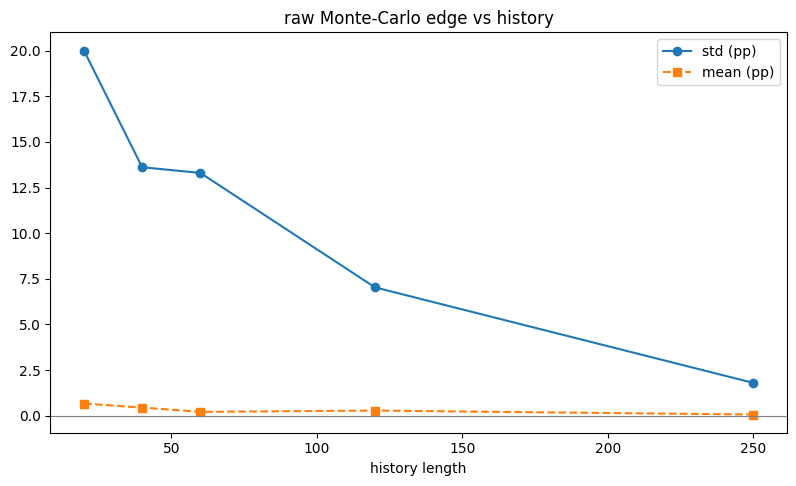

,mean_raw_edge_pp,std_raw_edge_pp,frac_positive
hist_len,,,
20,0.6700,20.0010,0.5430
40,0.4500,13.6100,0.4870
60,0.2140,13.2990,0.5230
120,0.2860,7.0320,0.5000
250,0.0690,1.8020,0.5070


In [4]:
hist = robustness.edge_vs_history(hist_lens=(20, 40, 60, 120, 250),
                                  n_markets=300, seed=0, system=SYS)
fig, ax = plt.subplots()
ax.plot(hist.index, hist['std_raw_edge_pp'], 'o-', label='std (pp)')
ax.plot(hist.index, hist['mean_raw_edge_pp'], 's--', label='mean (pp)')
ax.axhline(0, color='grey', lw=0.8); ax.set_xlabel('history length'); ax.legend()
ax.set_title('raw Monte-Carlo edge vs history'); plt.show()
hist.round(3)

**(c) The Markov stage is a noise *generator*, not a signal — and not inert.** Delete it (``raw_prob := price``) and the bet count collapses; the full pipeline's edge correlates weakly with the price-only version, so most of what it acts on is Monte-Carlo noise. The chain roughly **triples** the number of (coin-flip) bets.

In [5]:
inert = robustness.inertness(null, SYS, seed=0)
print('active share — full :', round(inert['active_frac_full'], 3),
      ' | ablated (price only):', round(inert['active_frac_ablated'], 3))
print('edge corr full-vs-ablated:', round(inert['edge_corr_full_vs_ablated'], 3),
      f"  (~{(1-inert['edge_corr_full_vs_ablated']**2)*100:.0f}% noise)")

active share — full : 0.578  | ablated (price only): 0.202
edge corr full-vs-ablated: 0.286   (~92% noise)


**(d) The calibration ceiling — a built-in reflex to short every strong favorite.** The table caps at 0.958, so any richer contract is handed a probability below its price → a forced **BUY NO**. On a *fair* market those shorts are zero-EV with lottery-ticket variance (a ~2¢ stake lost ~98% of the time), pure uncompensated risk for a Kelly book — and on a market where favorites are genuinely *underpriced* (the real-world favorite-longshot bias) they point exactly the wrong way. The top price bucket carries the most trades and the most extreme return profile.

{'ceiling': 0.958, 'floor': 0.0043, 'n_above_ceiling': 168, 'frac_above_ceiling': 0.336, 'frac_above_that_buy_no': 0.6011904761904762, 'n_below_floor': 57}


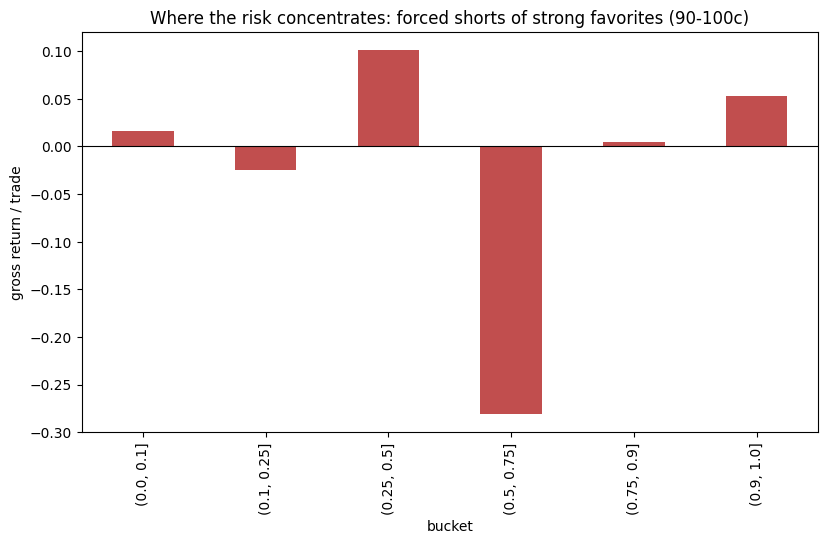

,n,mean_ret,win_rate,frac_buy_no,mean_cal_prob
bucket,,,,,
"(0.0, 0.1]",41,0.0170,0.9510,0.9760,0.0090
"(0.1, 0.25]",37,-0.0250,0.8110,0.9460,0.0420
"(0.25, 0.5]",28,0.1010,0.6070,0.6430,0.2790
"(0.5, 0.75]",29,-0.2810,0.3790,0.5170,0.6270
"(0.75, 0.9]",36,0.0040,0.8330,0.0560,0.9330
"(0.9, 1.0]",118,0.0530,0.1360,0.8560,0.9580


In [6]:
print(robustness.calibration_ceiling_effect(df))
bucket = robustness.pnl_by_price_bucket(df, spread=0.0)
ax = bucket['mean_ret'].plot(kind='bar', color='firebrick', alpha=0.8)
ax.axhline(0, color='k', lw=0.8); ax.set_ylabel('gross return / trade')
ax.set_title('Where the risk concentrates: forced shorts of strong favorites (90-100c)'); plt.show()
bucket.round(3)

## 5 · The Verdict

Headline (2,000 markets, results.md): **Signal NONE** (directional edge −0.45 pp, HAC *t* = −0.51; oracle 0); **Tradability MIRAGE** (terminal bankroll 0.0003× net of the 1¢ entry half-spread, 0.0017× at zero cost; per-trade Sharpe < 0); **'Win every trade' BUSTED** (win rate 51.5%). The raw-edge std falls ~20 → ~2 pp over history 20 → 250.

## 6 · Could You Trade It? — the planted-edge bound

On markets with a **real** planted wedge (longshots rich, favorites cheap — the Thaler-Ziemba direction), three benchmarks bound what's recoverable. The **machine** detects the edge gross — through its calibration table, not the chain (the ablated, price-only run captures it too) — and loses it all back to the toll, because it trades cost-blind. The **forced oracle** (true side on every market) is the gross ceiling but barely breaks even net. Only the **cost-aware oracle** — true probabilities *plus* the discipline to pass on toll-dominated markets — keeps a positive net mean: perfect information beats the spread only by trading selectively.

In [7]:
rec = robustness.recover_planted(wedge, SYS, spread=0.02, seed=1)
print(f"machine          : {rec['machine_edge_pp_gross']:+.2f} pp gross (t = {rec['machine_t']:+.2f})"
      f"  ->  {rec['machine_mean_ret_net']:+.2%}/trade net on {rec['machine_n_trades']} trades")
print(f"ablated (no chain): {rec['ablated_edge_pp_gross']:+.2f} pp gross (t = {rec['ablated_t']:+.2f})"
      f" on {rec['ablated_n_trades']} trades")
print(f"forced oracle    : {rec['oracle_forced_edge_pp_gross']:+.2f} pp gross"
      f"  ->  {rec['oracle_forced_mean_ret_net']:+.2%}/trade net (pays the toll everywhere)")
print(f"cost-aware oracle: trades {rec['oracle_aware_n_trades']}/{len(wedge)}"
      f"  ->  {rec['oracle_aware_mean_ret_net']:+.2%}/trade net (t = {rec['oracle_aware_t']:+.2f})")
print('forced-oracle gross edge by price bucket (pp):', rec['oracle_edge_by_price_bucket_pp'])

machine          : +3.37 pp gross (t = +1.86)  ->  -15.02%/trade net on 308 trades
ablated (no chain): -0.55 pp gross (t = -9.63) on 57 trades
forced oracle    : +1.70 pp gross  ->  +0.50%/trade net (pays the toll everywhere)
cost-aware oracle: trades 323/500  ->  +1.93%/trade net (t = +0.77)
forced-oracle gross edge by price bucket (pp): {'(0.0, 0.1]': 1.765, '(0.1, 0.25]': 3.48, '(0.25, 0.5]': -5.023, '(0.5, 0.75]': 4.277, '(0.75, 0.9]': 3.35, '(0.9, 1.0]': 1.769}


## 7 · Going Further

- A **path-dependent** market generator (genuine one-step memory the chain *could* catch — but calibration overwrites it).
- A **real Polymarket tape** to price the longshot bias net of true spreads.
- A **debugged pipeline** (uncapped calibration, YES = true resolution) to show it still reduces to 'bet the bias' and dies to the toll — i.e. the bugs aren't why it fails.
- An **adverse-selection maker model** to price the '+1.12% maker rebate' honestly.